<a href="https://colab.research.google.com/github/omR2/ThePythonQuants/blob/main/TheAIEngineer/GDOptimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. User-defined functions

In [1]:
#User-defined functions
def g(x): # represents g(x) on page 3 of the Handout
  return .5*(x-3)*x**2
def f(x): # represents f(x) on page 3 of the Handout
  return abs(g(x)) + .5*x
def g1(x): # represents g'(x) (unless x=3)
  return 3*x*(.5*x-1)
def f1(x): # represents f'(x) (unless x=3)
  if x<3: o = -g1(x)+.5
  elif x>=3: o = g1(x)+.5
  #else: o = [-4,5] #placeholder
  return o
def myIteration(x_0,                        #initial condition
                eta =.15,                   #proportional parameter
                minimizer=(3/2)-(8/9)*3**.5,#global minimizer
                threshold = .01,            #loop will stop if close enough
                epsilon =1e-09              #loop will stop if (almost) flat
                ):
  x = []
  x.append(x_0)
  if x_0<3:
    divergence = abs(x_0-minimizer)
    while divergence > threshold:
      x.append(x[-1] - eta*f1(x[-1]))
      if abs(x[-1]-x[-2]) < epsilon:
        break
      divergence = abs(x[-1]-minimizer)
  elif x_0>3:
    x.append(3)
  print("iteration finished at " + str(x[-1]))
  return x

## 1. Check analytic functions (f' calls g')
1. First derivative of f(x) at x=0
2. First derivative of f(x) at x=3

In [2]:
print(f1(0))
f1(3)

0.5


5.0

# 2. Check numeric approximation & Interpretation

The outputs are the complete trajectories, given an explicit initial condition and subject to default parameter values (including stopping rules)

The 0th element is the initial condition (starting point).

For each iteration step, the change in x is η-proportional to f'(x), for any value of x other than 3

In [3]:
myIteration(-1)

iteration finished at -0.15470053887964377


[-1,
 -0.4,
 -0.259,
 -0.20235677500000002,
 -0.17708286676260987,
 -0.165339949836741,
 -0.15978608013250392,
 -0.15713773600695222,
 -0.15586999448641084,
 -0.15526201955175736,
 -0.15497019444252624,
 -0.1548300606811397,
 -0.15476275514425863,
 -0.15473042549387786,
 -0.15471489549259163,
 -0.1547074352712866,
 -0.1547038515303583,
 -0.15470212996407345,
 -0.15470130295177065,
 -0.15470090566810438,
 -0.15470071481918776,
 -0.15470062313830055,
 -0.15470057909620513,
 -0.15470055793905504,
 -0.15470054777548292,
 -0.15470054289305785,
 -0.15470054054761528,
 -0.15470053942090042,
 -0.15470053887964377]

In [4]:
myIteration(.5)

iteration finished at -0.15470053763759425


[0.5,
 0.25625,
 0.0807119140625,
 -0.029142704324507718,
 -0.09083739550502645,
 -0.12310399523278381,
 -0.13929741380851962,
 -0.14724772945859385,
 -0.1511078250903166,
 -0.15297174946888084,
 -0.1538693820773812,
 -0.15430110812586276,
 -0.15450862227622894,
 -0.1546083365214438,
 -0.1546562440993603,
 -0.15467925964089096,
 -0.15469031629580285,
 -0.15469562782266008,
 -0.1546981794172875,
 -0.1546994051686279,
 -0.1546999940018517,
 -0.1547002768685795,
 -0.1547004127534953,
 -0.1547004780305495,
 -0.15470050938865412,
 -0.15470052445261023,
 -0.15470053168910528,
 -0.15470053516540722,
 -0.15470053683536972,
 -0.15470053763759425]

In [5]:
myIteration(2)

iteration finished at -0.15470053788059446


[2,
 1.925,
 1.817515625,
 1.6678902793518067,
 1.4682577000336494,
 1.2175923866028302,
 0.9282453371120212,
 0.6294038017324088,
 0.360305648720747,
 0.15237764290892847,
 0.014031966463068868,
 -0.06723811682667748,
 -0.11096374727493308,
 -0.13325964652912178,
 -0.14429722557757704,
 -0.1496785939730555,
 -0.1522823983490866,
 -0.15353758510143392,
 -0.15414156904706314,
 -0.15443194773151936,
 -0.15457149529430173,
 -0.15463854430142476,
 -0.1546707565044593,
 -0.1546862314209787,
 -0.15469366548851277,
 -0.15469723673667085,
 -0.1546989523180276,
 -0.15469977645904873,
 -0.1547001723642689,
 -0.15470036255120262,
 -0.1547004539141299,
 -0.15470049780349293,
 -0.1547005188872752,
 -0.1547005290156031,
 -0.15470053388109753,
 -0.1547005362184069,
 -0.1547005373412147,
 -0.15470053788059446]

In [6]:
myIteration(3)

iteration finished at 3


[3]

In [7]:
myIteration(10)

iteration finished at 3


[10, 3]

iteration finished at -0.15470053887964377
iteration finished at -0.15470053763759425
iteration finished at -0.15470053788059446


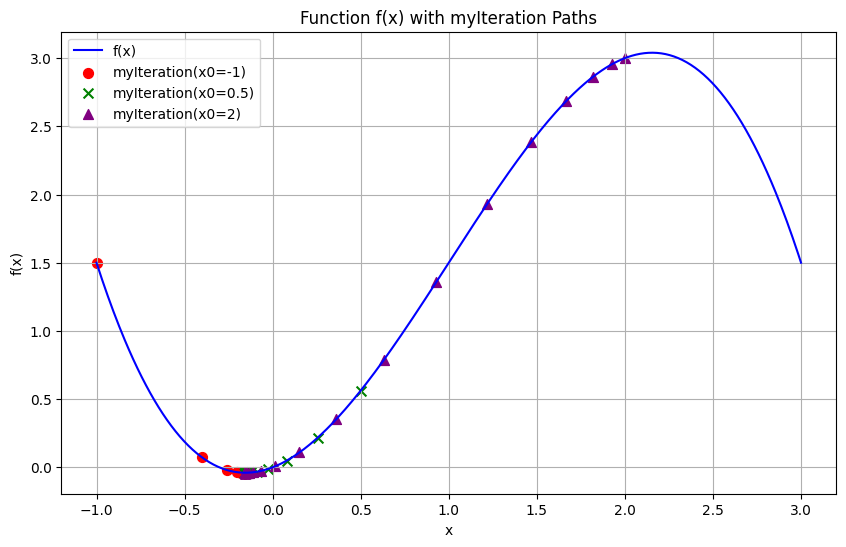

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the domain for x and calculate f(x) values
x_domain = np.linspace(-1, 3, 500) # 500 points for a smooth curve
y_f = [f(val) for val in x_domain]

# 2. Get the results of myIteration for each initial condition
iter_neg1 = myIteration(-1)
iter_point5 = myIteration(0.5)
iter_2 = myIteration(2)

# 3. Create the plot
plt.figure(figsize=(10, 6))

# Plot the function f(x)
plt.plot(x_domain, y_f, label='f(x)', color='blue')

# Plot the myIteration instances
plt.scatter(iter_neg1, [f(x_val) for x_val in iter_neg1], color='red', marker='o', s=50, label='myIteration(x0=-1)')
plt.scatter(iter_point5, [f(x_val) for x_val in iter_point5], color='green', marker='x', s=50, label='myIteration(x0=0.5)')
plt.scatter(iter_2, [f(x_val) for x_val in iter_2], color='purple', marker='^', s=50, label='myIteration(x0=2)')

# 4. Add labels, title, and legend
plt.title('Function f(x) with myIteration Paths')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
from google.colab import drive
drive.mount('/content/drive')
import os
repo_path = '/content/drive/MyDrive/The Python Quants/OmR2/TheAIEngineer'
os.chdir(repo_path)
print(f"Current working directory: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current working directory: /content/drive/MyDrive/The Python Quants/OmR2/TheAIEngineer


In [10]:
plt.savefig(repo_path + '/GDOptimization.png')


<Figure size 640x480 with 0 Axes>

In [11]:
!ls -F '{repo_path}'

GDOptimization.ipynb  GDOptimization.png
